In [3]:
import pandas as pd
import numpy as np
import os

print(os.getcwd())
print(os.listdir())
print("Python is working!")
print(pd.__version__)

c:\Github\retail-financial-intelligence\notebooks
['01_data_understanding.ipynb']
Python is working!
3.0.5


In [4]:
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

In [5]:
file_path = "c:\\Github\\retail-financial-intelligence\\data\\raw\\online_retail_II.xlsx"

excel_file = pd.ExcelFile(file_path)

print(excel_file.sheet_names)

['Year 2009-2010', 'Year 2010-2011']


In [6]:
for sheet in excel_file.sheet_names:
    temp = pd.read_excel(file_path, sheet_name=sheet)
    print(sheet, temp.shape)

Year 2009-2010 (525461, 8)
Year 2010-2011 (541910, 8)


In [7]:
df_2009_2010 = pd.read_excel(
    file_path,
    sheet_name="Year 2009-2010"
)

df_2010_2011 = pd.read_excel(
    file_path,
    sheet_name="Year 2010-2011"
)

df = pd.concat(
    [df_2009_2010, df_2010_2011],
    ignore_index=True
)

df.tail()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
1067366,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
1067367,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
1067368,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France
1067369,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.95,12680.0,France
1067370,581587,POST,POSTAGE,1,2011-12-09 12:50:00,18.00,12680.0,France


In [8]:
rows, columns = df.shape

print("Number of rows:", rows)
print("Number of columns:", columns)

Number of rows: 1067371
Number of columns: 8


In [9]:
df.columns.tolist()

['Invoice',
 'StockCode',
 'Description',
 'Quantity',
 'InvoiceDate',
 'Price',
 'Customer ID',
 'Country']

In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype         
---  ------       --------------    -----         
 0   Invoice      1067371 non-null  object        
 1   StockCode    1067371 non-null  object        
 2   Description  1062989 non-null  object        
 3   Quantity     1067371 non-null  int64         
 4   InvoiceDate  1067371 non-null  datetime64[us]
 5   Price        1067371 non-null  float64       
 6   Customer ID  824364 non-null   float64       
 7   Country      1067371 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 65.1+ MB


In [11]:
df.duplicated().sum()

np.int64(34335)

In [12]:
df.isnull().sum()

Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64

In [13]:
missing = df.isnull().sum()

missing_percentage = (
    df.isnull().sum() / len(df) * 100
).round(2)

missing_summary = pd.DataFrame({
    "Missing Values": missing,
    "Missing Percentage": missing_percentage
})

missing_summary.sort_values(
    "Missing Values",
    ascending=False
)

,Missing Values,Missing Percentage
Customer ID,243007,22.77
Description,4382,0.41
StockCode,0,0.00
Invoice,0,0.00
Quantity,0,0.00
InvoiceDate,0,0.00
Price,0,0.00
Country,0,0.00


In [14]:
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 34335


In [15]:
df.describe()

,Quantity,InvoiceDate,Price,Customer ID
count,1.067371e+06,1067371,1.067371e+06,824364.000000
mean,9.938898e+00,2011-01-02 21:13:55.394029,4.649388e+00,15324.638504
min,-8.099500e+04,2009-12-01 07:45:00,-5.359436e+04,12346.000000
25%,1.000000e+00,2010-07-09 09:46:00,1.250000e+00,13975.000000
50%,3.000000e+00,2010-12-07 15:28:00,2.100000e+00,15255.000000
75%,1.000000e+01,2011-07-22 10:23:00,4.150000e+00,16797.000000
max,8.099500e+04,2011-12-09 12:50:00,3.897000e+04,18287.000000
std,1.727058e+02,NaN,1.235531e+02,1697.464450


In [16]:
pd.set_option("display.float_format", "{:,.2f}".format)

In [17]:
country_counts = (
    df["Country"]
    .value_counts()
)

country_counts.head(20)

Country
United Kingdom     981330
EIRE                17866
Germany             17624
France              14330
Netherlands          5140
Spain                3811
Switzerland          3189
Belgium              3123
Portugal             2620
Australia            1913
Channel Islands      1664
Italy                1534
Norway               1455
Sweden               1364
Cyprus               1176
Finland              1049
Austria               938
Denmark               817
Unspecified           756
Greece                663
Name: count, dtype: int64

In [18]:
customer_counts = (
    df["Customer ID"]
    .value_counts()
)

customer_counts.head(20)

Customer ID
17,841.00    13097
14,911.00    11613
12,748.00     7307
14,606.00     6709
14,096.00     5128
15,311.00     4717
14,156.00     4130
14,646.00     3890
13,089.00     3438
16,549.00     3255
14,298.00     2868
14,527.00     2837
17,850.00     2827
15,039.00     2810
15,005.00     2548
13,081.00     2430
17,511.00     2134
13,263.00     1920
16,782.00     1900
14,159.00     1885
Name: count, dtype: int64

In [19]:
product_counts = (
    df["StockCode"]
    .value_counts()
)

product_counts.head(20)

StockCode
85123A    5829
22423     4424
85099B    4216
21212     3318
20725     3259
84879     2960
47566     2768
21232     2747
22197     2549
22383     2540
20727     2529
21931     2434
22386     2347
22469     2325
22411     2297
84991     2271
22382     2251
22384     2230
21080     2224
22086     2217
Name: count, dtype: int64

In [20]:
invoice_counts = (
    df["Invoice"]
    .value_counts()
)

invoice_counts.head(20)

Invoice
537434    1350
538071    1304
537638    1202
537237    1194
536876    1186
536592    1184
537823    1182
537240    1136
573585    1114
537666    1072
536544    1054
581219     749
581492     731
580729     721
558475     705
579777     687
581217     676
580730     662
580367     650
580115     645
Name: count, dtype: int64

In [21]:
df[df.Invoice == 537434]

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
516208,537434,20685,DOORMAT RED RETROSPOT,1,2010-12-06 16:57:00,14.43,NaN,United Kingdom
516209,537434,20699,MOUSEY LONG LEGS SOFT TOY,1,2010-12-06 16:57:00,5.06,NaN,United Kingdom
516210,537434,20713,JUMBO BAG OWLS,1,2010-12-06 16:57:00,4.21,NaN,United Kingdom
516211,537434,20719,WOODLAND CHARLOTTE BAG,3,2010-12-06 16:57:00,1.66,NaN,United Kingdom
516212,537434,20725,LUNCH BAG RED RETROSPOT,4,2010-12-06 16:57:00,4.21,NaN,United Kingdom
...,...,...,...,...,...,...,...,...
539401,537434,20652,BLUE POLKADOT LUGGAGE TAG,2,2010-12-06 16:57:00,2.51,NaN,United Kingdom
539402,537434,20658,RED RETROSPOT LUGGAGE TAG,1,2010-12-06 16:57:00,2.51,NaN,United Kingdom
539403,537434,20665,RED RETROSPOT PURSE,1,2010-12-06 16:57:00,5.91,NaN,United Kingdom
539404,537434,20682,RED RETROSPOT CHILDRENS UMBRELLA,1,2010-12-06 16:57:00,6.77,NaN,United Kingdom


In [22]:
df["Invoice"].astype(str).str.startswith("C").value_counts()

Invoice
False    1047877
True       19494
Name: count, dtype: int64

In [23]:
df["IsCancelled"] = (
    df["Invoice"]
    .astype(str)
    .str.startswith("C")
)

In [24]:
df["IsCancelled"].value_counts(normalize=True) * 100

IsCancelled
False   98.17
True     1.83
Name: proportion, dtype: float64

In [25]:
df["InvoiceDate"] = pd.to_datetime(
    df["InvoiceDate"],
    errors="coerce"
)

In [26]:
print("Earliest transaction:", df["InvoiceDate"].min())
print("Latest transaction:", df["InvoiceDate"].max())

Earliest transaction: 2009-12-01 07:45:00
Latest transaction: 2011-12-09 12:50:00


In [27]:
df["Quantity"].describe()  #why thw qty is negative?

count   1,067,371.00
mean            9.94
std           172.71
min       -80,995.00
25%             1.00
50%             3.00
75%            10.00
max        80,995.00
Name: Quantity, dtype: float64

In [28]:
negative_quantity = (
    df["Quantity"] < 0
).sum()

print(
    "Transactions with negative quantity:",
    negative_quantity
)

Transactions with negative quantity: 22950


In [29]:
df["Price"].describe() #why the price is negative?

count   1,067,371.00
mean            4.65
std           123.55
min       -53,594.36
25%             1.25
50%             2.10
75%             4.15
max        38,970.00
Name: Price, dtype: float64

In [30]:
zero_or_negative_price = (
    df["Price"] <= 0
).sum()

print(
    "Transactions with zero or negative price:",
    zero_or_negative_price
)

Transactions with zero or negative price: 6207


In [31]:
df["Revenue"] = (
    df["Quantity"] *
    df["Price"]
)

df["Revenue"].describe()

count   1,067,371.00
mean           18.07
std           292.42
min      -168,469.60
25%             3.75
50%             9.90
75%            17.70
max       168,469.60
Name: Revenue, dtype: float64

In [32]:
print(
    "Total transaction value:",
    df["Revenue"].sum()
)

Total transaction value: 19287250.568


In [33]:
revenue_by_country = (
    df.groupby("Country")["Revenue"]
    .sum()
    .sort_values(ascending=False)
)

revenue_by_country.head(15)

Country
United Kingdom    16,382,583.90
EIRE                 615,519.55
Netherlands          548,524.95
Germany              417,988.56
France               328,191.80
Australia            167,129.07
Switzerland           99,728.76
Spain                 91,859.48
Sweden                87,809.42
Denmark               65,741.09
Belgium               63,574.49
Portugal              53,136.80
Japan                 43,776.58
Channel Islands       41,453.61
Norway                39,243.03
Name: Revenue, dtype: float64

In [34]:
monthly_transactions = (
    df.set_index("InvoiceDate")
      .resample("ME")["Invoice"]
      .size()
)

monthly_transactions.head()

InvoiceDate
2009-12-31    45228
2010-01-31    31555
2010-02-28    29388
2010-03-31    41511
2010-04-30    34057
Freq: ME, Name: Invoice, dtype: int64

In [35]:
monthly_revenue = (
    df.set_index("InvoiceDate")["Revenue"]
      .resample("ME")
      .sum()
)

monthly_revenue.head()

InvoiceDate
2009-12-31   799,847.11
2010-01-31   624,032.89
2010-02-28   533,091.43
2010-03-31   765,848.76
2010-04-30   590,580.43
Freq: ME, Name: Revenue, dtype: float64

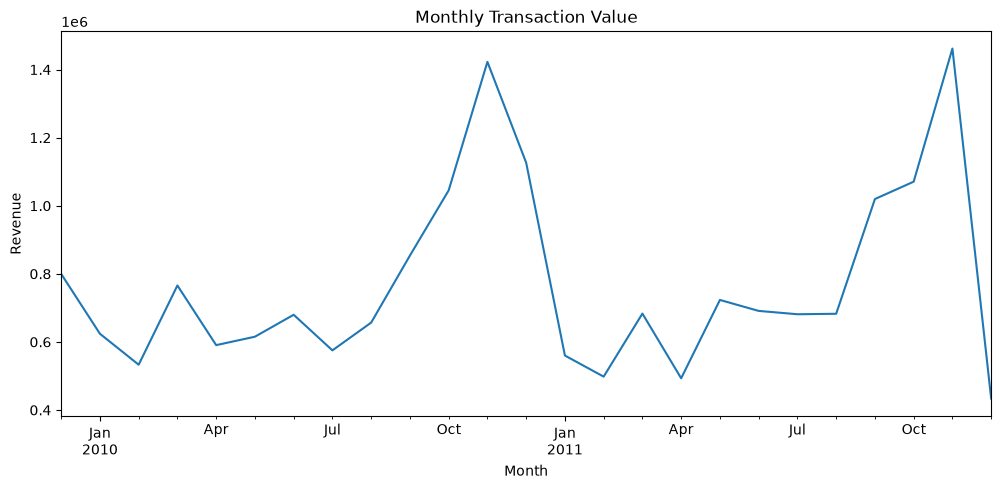

In [36]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

monthly_revenue.plot()

plt.title("Monthly Transaction Value")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.show()

In [37]:
df[["Quantity", "Price"]].head(20)

,Quantity,Price
0,12,6.95
1,12,6.75
2,12,6.75
3,48,2.10
4,24,1.25
5,24,1.65
6,24,1.25
7,10,5.95
8,12,2.55
9,12,3.75


In [38]:
df[["Quantity", "Price"]].describe()

,Quantity,Price
count,"1,067,371.00","1,067,371.00"
mean,9.94,4.65
std,172.71,123.55
min,"-80,995.00","-53,594.36"
25%,1.00,1.25
50%,3.00,2.10
75%,10.00,4.15
max,"80,995.00","38,970.00"


In [39]:
df.nlargest(20, "Quantity")[["Invoice", "StockCode", "Quantity", "Price"]]

,Invoice,StockCode,Quantity,Price
1065882,581483,23843,80995,2.08
587080,541431,23166,74215,1.04
90857,497946,37410,19152,0.10
127166,501534,21099,12960,0.10
127168,501534,21091,12960,0.10
127169,501534,21085,12744,0.10
1027583,578841,84826,12540,0.00
127167,501534,21092,12480,0.10
192197,507637,84016,10200,0.00
135027,502269,21984,10000,0.25


In [40]:
df.nlargest(20, "Price")[["Invoice", "StockCode", "Quantity", "Price"]]

,Invoice,StockCode,Quantity,Price
748142,C556445,M,-1,"38,970.00"
241824,C512770,M,-1,"25,111.09"
241827,512771,M,1,"25,111.09"
320581,C520667,BANK CHARGES,-1,"18,910.69"
1050063,C580605,AMAZONFEE,-1,"17,836.46"
569163,C540117,AMAZONFEE,-1,"16,888.02"
569164,C540118,AMAZONFEE,-1,"16,453.71"
517953,C537630,AMAZONFEE,-1,"13,541.33"
517955,537632,AMAZONFEE,1,"13,541.33"
519294,C537651,AMAZONFEE,-1,"13,541.33"


In [41]:
df.groupby("IsCancelled")["Quantity"].agg(
    ["count", "min", "max", "mean", "median"]
)

,count,min,max,mean,median
IsCancelled,,,,,
False,1047877,-9600,80995,10.59,3.00
True,19494,-80995,1,-25.19,-2.00


In [42]:
df.groupby("IsCancelled")["Price"].agg(
    ["count", "min", "max", "mean", "median"]
)

,count,min,max,mean,median
IsCancelled,,,,,
False,1047877,"-53,594.36","25,111.09",3.90,2.10
True,19494,0.01,"38,970.00",44.87,2.95


In [43]:
df[df["Price"] == df["Price"].max()]

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,IsCancelled,Revenue
748142,C556445,M,Manual,-1,2011-06-10 15:31:00,"38,970.00","15,098.00",United Kingdom,True,"-38,970.00"


In [44]:
df[df["Price"] < 0][
    ["Invoice", "StockCode", "Description",
     "Quantity", "Price", "InvoiceDate",
     "Customer ID", "Country"]
].head(20)

,Invoice,StockCode,Description,Quantity,Price,InvoiceDate,Customer ID,Country
179403,A506401,B,Adjust bad debt,1,"-53,594.36",2010-04-29 13:36:00,NaN,United Kingdom
276274,A516228,B,Adjust bad debt,1,"-44,031.79",2010-07-19 11:24:00,NaN,United Kingdom
403472,A528059,B,Adjust bad debt,1,"-38,925.87",2010-10-20 12:04:00,NaN,United Kingdom
825444,A563186,B,Adjust bad debt,1,"-11,062.06",2011-08-12 14:51:00,NaN,United Kingdom
825445,A563187,B,Adjust bad debt,1,"-11,062.06",2011-08-12 14:52:00,NaN,United Kingdom


In [45]:
df["Revenue"] = df["Quantity"] * df["Price"]

In [46]:
df["Revenue"].describe()

count   1,067,371.00
mean           18.07
std           292.42
min      -168,469.60
25%             3.75
50%             9.90
75%            17.70
max       168,469.60
Name: Revenue, dtype: float64

In [47]:
duplicate_rows = df[df.duplicated(keep=False)]

duplicate_rows.head(20)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,IsCancelled,Revenue
362,489517,21913,VINTAGE SEASIDE JIGSAW PUZZLES,1,2009-12-01 11:34:00,3.75,"16,329.00",United Kingdom,False,3.75
363,489517,21912,VINTAGE SNAKES & LADDERS,1,2009-12-01 11:34:00,3.75,"16,329.00",United Kingdom,False,3.75
365,489517,21821,GLITTER STAR GARLAND WITH BELLS,1,2009-12-01 11:34:00,3.75,"16,329.00",United Kingdom,False,3.75
367,489517,22319,HAIRCLIPS FORTIES FABRIC ASSORTED,12,2009-12-01 11:34:00,0.65,"16,329.00",United Kingdom,False,7.80
368,489517,22130,PARTY CONE CHRISTMAS DECORATION,6,2009-12-01 11:34:00,0.85,"16,329.00",United Kingdom,False,5.10
371,489517,21912,VINTAGE SNAKES & LADDERS,1,2009-12-01 11:34:00,3.75,"16,329.00",United Kingdom,False,3.75
379,489517,21491,SET OF THREE VINTAGE GIFT WRAPS,1,2009-12-01 11:34:00,1.95,"16,329.00",United Kingdom,False,1.95
383,489517,22130,PARTY CONE CHRISTMAS DECORATION,6,2009-12-01 11:34:00,0.85,"16,329.00",United Kingdom,False,5.10
384,489517,22319,HAIRCLIPS FORTIES FABRIC ASSORTED,12,2009-12-01 11:34:00,0.65,"16,329.00",United Kingdom,False,7.80
385,489517,21913,VINTAGE SEASIDE JIGSAW PUZZLES,1,2009-12-01 11:34:00,3.75,"16,329.00",United Kingdom,False,3.75


In [48]:
duplicate_rows.shape

(67242, 10)

In [49]:
duplicate_rows.sort_values(
    ["Invoice", "StockCode", "InvoiceDate"]
).head(30)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,IsCancelled,Revenue
379,489517,21491,SET OF THREE VINTAGE GIFT WRAPS,1,2009-12-01 11:34:00,1.95,"16,329.00",United Kingdom,False,1.95
391,489517,21491,SET OF THREE VINTAGE GIFT WRAPS,1,2009-12-01 11:34:00,1.95,"16,329.00",United Kingdom,False,1.95
365,489517,21821,GLITTER STAR GARLAND WITH BELLS,1,2009-12-01 11:34:00,3.75,"16,329.00",United Kingdom,False,3.75
386,489517,21821,GLITTER STAR GARLAND WITH BELLS,1,2009-12-01 11:34:00,3.75,"16,329.00",United Kingdom,False,3.75
363,489517,21912,VINTAGE SNAKES & LADDERS,1,2009-12-01 11:34:00,3.75,"16,329.00",United Kingdom,False,3.75
371,489517,21912,VINTAGE SNAKES & LADDERS,1,2009-12-01 11:34:00,3.75,"16,329.00",United Kingdom,False,3.75
394,489517,21912,VINTAGE SNAKES & LADDERS,1,2009-12-01 11:34:00,3.75,"16,329.00",United Kingdom,False,3.75
362,489517,21913,VINTAGE SEASIDE JIGSAW PUZZLES,1,2009-12-01 11:34:00,3.75,"16,329.00",United Kingdom,False,3.75
385,489517,21913,VINTAGE SEASIDE JIGSAW PUZZLES,1,2009-12-01 11:34:00,3.75,"16,329.00",United Kingdom,False,3.75
368,489517,22130,PARTY CONE CHRISTMAS DECORATION,6,2009-12-01 11:34:00,0.85,"16,329.00",United Kingdom,False,5.10


In [50]:
cancelled = df[df["IsCancelled"]]

cancelled.head(20)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,IsCancelled,Revenue
178,C489449,22087,PAPER BUNTING WHITE LACE,-12,2009-12-01 10:33:00,2.95,"16,321.00",Australia,True,-35.40
179,C489449,85206A,CREAM FELT EASTER EGG BASKET,-6,2009-12-01 10:33:00,1.65,"16,321.00",Australia,True,-9.90
180,C489449,21895,POTTING SHED SOW 'N' GROW SET,-4,2009-12-01 10:33:00,4.25,"16,321.00",Australia,True,-17.00
181,C489449,21896,POTTING SHED TWINE,-6,2009-12-01 10:33:00,2.10,"16,321.00",Australia,True,-12.60
182,C489449,22083,PAPER CHAIN KIT RETRO SPOT,-12,2009-12-01 10:33:00,2.95,"16,321.00",Australia,True,-35.40
183,C489449,21871,SAVE THE PLANET MUG,-12,2009-12-01 10:33:00,1.25,"16,321.00",Australia,True,-15.00
184,C489449,84946,ANTIQUE SILVER TEA GLASS ETCHED,-12,2009-12-01 10:33:00,1.25,"16,321.00",Australia,True,-15.00
185,C489449,84970S,HANGING HEART ZINC T-LIGHT HOLDER,-24,2009-12-01 10:33:00,0.85,"16,321.00",Australia,True,-20.40
186,C489449,22090,PAPER BUNTING RETRO SPOTS,-12,2009-12-01 10:33:00,2.95,"16,321.00",Australia,True,-35.40
196,C489459,90200A,PURPLE SWEETHEART BRACELET,-3,2009-12-01 10:44:00,4.25,"17,592.00",United Kingdom,True,-12.75


In [51]:
cancelled[[
    "Invoice",
    "StockCode",
    "Description",
    "Quantity",
    "Price",
    "InvoiceDate",
    "Customer ID",
    "Country"
]].head(20)

,Invoice,StockCode,Description,Quantity,Price,InvoiceDate,Customer ID,Country
178,C489449,22087,PAPER BUNTING WHITE LACE,-12,2.95,2009-12-01 10:33:00,"16,321.00",Australia
179,C489449,85206A,CREAM FELT EASTER EGG BASKET,-6,1.65,2009-12-01 10:33:00,"16,321.00",Australia
180,C489449,21895,POTTING SHED SOW 'N' GROW SET,-4,4.25,2009-12-01 10:33:00,"16,321.00",Australia
181,C489449,21896,POTTING SHED TWINE,-6,2.10,2009-12-01 10:33:00,"16,321.00",Australia
182,C489449,22083,PAPER CHAIN KIT RETRO SPOT,-12,2.95,2009-12-01 10:33:00,"16,321.00",Australia
183,C489449,21871,SAVE THE PLANET MUG,-12,1.25,2009-12-01 10:33:00,"16,321.00",Australia
184,C489449,84946,ANTIQUE SILVER TEA GLASS ETCHED,-12,1.25,2009-12-01 10:33:00,"16,321.00",Australia
185,C489449,84970S,HANGING HEART ZINC T-LIGHT HOLDER,-24,0.85,2009-12-01 10:33:00,"16,321.00",Australia
186,C489449,22090,PAPER BUNTING RETRO SPOTS,-12,2.95,2009-12-01 10:33:00,"16,321.00",Australia
196,C489459,90200A,PURPLE SWEETHEART BRACELET,-3,4.25,2009-12-01 10:44:00,"17,592.00",United Kingdom


In [52]:
df.groupby("IsCancelled")[["Quantity", "Price"]].agg(
    ["count", "min", "mean", "median", "max"]
)

Quantity                                Price                   \
               count    min   mean median    max    count        min  mean   
IsCancelled                                                                  
False        1047877  -9600  10.59   3.00  80995  1047877 -53,594.36  3.90   
True           19494 -80995 -25.19  -2.00      1    19494       0.01 44.87   

                              
            median       max  
IsCancelled                   
False         2.10 25,111.09  
True          2.95 38,970.00

9.Investigating negative quantity

In [53]:
(df["Quantity"] < 0).sum()

np.int64(22950)

In [54]:
df[df["Quantity"] < 0][[
    "Invoice",
    "StockCode",
    "Description",
    "Quantity",
    "Price",
    "InvoiceDate",
    "Customer ID",
    "Country",
    "IsCancelled"
]].head(20)

,Invoice,StockCode,Description,Quantity,Price,InvoiceDate,Customer ID,Country,IsCancelled
178,C489449,22087,PAPER BUNTING WHITE LACE,-12,2.95,2009-12-01 10:33:00,"16,321.00",Australia,True
179,C489449,85206A,CREAM FELT EASTER EGG BASKET,-6,1.65,2009-12-01 10:33:00,"16,321.00",Australia,True
180,C489449,21895,POTTING SHED SOW 'N' GROW SET,-4,4.25,2009-12-01 10:33:00,"16,321.00",Australia,True
181,C489449,21896,POTTING SHED TWINE,-6,2.10,2009-12-01 10:33:00,"16,321.00",Australia,True
182,C489449,22083,PAPER CHAIN KIT RETRO SPOT,-12,2.95,2009-12-01 10:33:00,"16,321.00",Australia,True
183,C489449,21871,SAVE THE PLANET MUG,-12,1.25,2009-12-01 10:33:00,"16,321.00",Australia,True
184,C489449,84946,ANTIQUE SILVER TEA GLASS ETCHED,-12,1.25,2009-12-01 10:33:00,"16,321.00",Australia,True
185,C489449,84970S,HANGING HEART ZINC T-LIGHT HOLDER,-24,0.85,2009-12-01 10:33:00,"16,321.00",Australia,True
186,C489449,22090,PAPER BUNTING RETRO SPOTS,-12,2.95,2009-12-01 10:33:00,"16,321.00",Australia,True
196,C489459,90200A,PURPLE SWEETHEART BRACELET,-3,4.25,2009-12-01 10:44:00,"17,592.00",United Kingdom,True


In [55]:
pd.crosstab(
    df["Quantity"] < 0,
    df["IsCancelled"]
)

IsCancelled,False,True
Quantity,,
False,1044420,1
True,3457,19493


In [56]:
(df["Price"] < 0).sum()

np.int64(5)

In [57]:
df[df["Price"] < 0][[
    "Invoice",
    "StockCode",
    "Description",
    "Quantity",
    "Price",
    "InvoiceDate",
    "Customer ID",
    "Country",
    "IsCancelled"
]].head(30)

,Invoice,StockCode,Description,Quantity,Price,InvoiceDate,Customer ID,Country,IsCancelled
179403,A506401,B,Adjust bad debt,1,"-53,594.36",2010-04-29 13:36:00,NaN,United Kingdom,False
276274,A516228,B,Adjust bad debt,1,"-44,031.79",2010-07-19 11:24:00,NaN,United Kingdom,False
403472,A528059,B,Adjust bad debt,1,"-38,925.87",2010-10-20 12:04:00,NaN,United Kingdom,False
825444,A563186,B,Adjust bad debt,1,"-11,062.06",2011-08-12 14:51:00,NaN,United Kingdom,False
825445,A563187,B,Adjust bad debt,1,"-11,062.06",2011-08-12 14:52:00,NaN,United Kingdom,False


In [58]:
df["Revenue"].head(20)

0     83.40
1     81.00
2     81.00
3    100.80
4     30.00
5     39.60
6     30.00
7     59.50
8     30.60
9     45.00
10    39.60
11    30.60
12    59.50
13    98.10
14    17.85
15    27.04
16    20.85
17    17.40
18    19.80
19    19.80
Name: Revenue, dtype: float64

In [59]:
df["Revenue"] = df["Quantity"] * df["Price"]
df["Revenue"]

0          83.40
1          81.00
2          81.00
3         100.80
4          30.00
           ...  
1067366    12.60
1067367    16.60
1067368    16.60
1067369    14.85
1067370    18.00
Name: Revenue, Length: 1067371, dtype: float64

In [60]:
duplicate_rows = df[df.duplicated(keep=False)]
duplicate_rows.sort_values(
    ["Invoice", "StockCode", "InvoiceDate"]
).head(30)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,IsCancelled,Revenue
379,489517,21491,SET OF THREE VINTAGE GIFT WRAPS,1,2009-12-01 11:34:00,1.95,"16,329.00",United Kingdom,False,1.95
391,489517,21491,SET OF THREE VINTAGE GIFT WRAPS,1,2009-12-01 11:34:00,1.95,"16,329.00",United Kingdom,False,1.95
365,489517,21821,GLITTER STAR GARLAND WITH BELLS,1,2009-12-01 11:34:00,3.75,"16,329.00",United Kingdom,False,3.75
386,489517,21821,GLITTER STAR GARLAND WITH BELLS,1,2009-12-01 11:34:00,3.75,"16,329.00",United Kingdom,False,3.75
363,489517,21912,VINTAGE SNAKES & LADDERS,1,2009-12-01 11:34:00,3.75,"16,329.00",United Kingdom,False,3.75
371,489517,21912,VINTAGE SNAKES & LADDERS,1,2009-12-01 11:34:00,3.75,"16,329.00",United Kingdom,False,3.75
394,489517,21912,VINTAGE SNAKES & LADDERS,1,2009-12-01 11:34:00,3.75,"16,329.00",United Kingdom,False,3.75
362,489517,21913,VINTAGE SEASIDE JIGSAW PUZZLES,1,2009-12-01 11:34:00,3.75,"16,329.00",United Kingdom,False,3.75
385,489517,21913,VINTAGE SEASIDE JIGSAW PUZZLES,1,2009-12-01 11:34:00,3.75,"16,329.00",United Kingdom,False,3.75
368,489517,22130,PARTY CONE CHRISTMAS DECORATION,6,2009-12-01 11:34:00,0.85,"16,329.00",United Kingdom,False,5.10


In [61]:
(df["Quantity"] < 0).sum()

np.int64(22950)

In [62]:
(df["Price"] < 0).sum()

np.int64(5)

In [63]:
quality_summary = pd.DataFrame({
    "Missing": df.isna().sum(),
    "Missing_%": df.isna().mean() * 100,
    "Unique": df.nunique(),
    "DataType": df.dtypes.astype(str)
})

quality_summary

,Missing,Missing_%,Unique,DataType
Invoice,0,0.00,53628,object
StockCode,0,0.00,5305,object
Description,4382,0.41,5698,object
Quantity,0,0.00,1057,int64
InvoiceDate,0,0.00,47635,datetime64[us]
Price,0,0.00,2807,float64
Customer ID,243007,22.77,5942,float64
Country,0,0.00,43,str
IsCancelled,0,0.00,2,bool
Revenue,0,0.00,9113,float64


In [64]:
negative_not_cancelled = df[
    (df["Quantity"] < 0) &
    (df["IsCancelled"] == False)
]

negative_not_cancelled[
    [
        "Invoice",
        "StockCode",
        "Description",
        "Quantity",
        "Price",
        "InvoiceDate",
        "Customer ID",
        "Country"
    ]
].head(30)

,Invoice,StockCode,Description,Quantity,Price,InvoiceDate,Customer ID,Country
263,489464,21733,85123a mixed,-96,0.00,2009-12-01 10:52:00,NaN,United Kingdom
283,489463,71477,short,-240,0.00,2009-12-01 10:52:00,NaN,United Kingdom
284,489467,85123A,21733 mixed,-192,0.00,2009-12-01 10:53:00,NaN,United Kingdom
470,489521,21646,NaN,-50,0.00,2009-12-01 11:44:00,NaN,United Kingdom
3114,489655,20683,NaN,-44,0.00,2009-12-01 17:26:00,NaN,United Kingdom
3162,489660,35956,lost,-1043,0.00,2009-12-01 17:43:00,NaN,United Kingdom
3168,489663,35605A,damages,-117,0.00,2009-12-01 18:02:00,NaN,United Kingdom
4296,489806,18010,NaN,-770,0.00,2009-12-02 12:42:00,NaN,United Kingdom
4538,489820,21133,invcd as 84879?,-720,0.00,2009-12-02 13:23:00,NaN,United Kingdom
4566,489821,85049G,NaN,-240,0.00,2009-12-02 13:25:00,NaN,United Kingdom


In [65]:
negative_not_cancelled.shape

(3457, 10)

In [66]:
negative_not_cancelled["Invoice"].head(20)

263      489464
283      489463
284      489467
470      489521
3114     489655
3162     489660
3168     489663
4296     489806
4538     489820
4566     489821
6556     489899
6576     489901
6911     490007
7205     490016
7559     490055
8553     490084
9308     490130
9667     490146
10508    490165
11973    490354
Name: Invoice, dtype: object

In [67]:
df[df["Price"] < 0][
    [
        "Invoice",
        "StockCode",
        "Description",
        "Quantity",
        "Price",
        "InvoiceDate",
        "Customer ID",
        "Country",
        "IsCancelled"
    ]
]

,Invoice,StockCode,Description,Quantity,Price,InvoiceDate,Customer ID,Country,IsCancelled
179403,A506401,B,Adjust bad debt,1,"-53,594.36",2010-04-29 13:36:00,NaN,United Kingdom,False
276274,A516228,B,Adjust bad debt,1,"-44,031.79",2010-07-19 11:24:00,NaN,United Kingdom,False
403472,A528059,B,Adjust bad debt,1,"-38,925.87",2010-10-20 12:04:00,NaN,United Kingdom,False
825444,A563186,B,Adjust bad debt,1,"-11,062.06",2011-08-12 14:51:00,NaN,United Kingdom,False
825445,A563187,B,Adjust bad debt,1,"-11,062.06",2011-08-12 14:52:00,NaN,United Kingdom,False


In [68]:
df[df["StockCode"] =='B']

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,IsCancelled,Revenue
179403,A506401,B,Adjust bad debt,1,2010-04-29 13:36:00,"-53,594.36",NaN,United Kingdom,False,"-53,594.36"
276274,A516228,B,Adjust bad debt,1,2010-07-19 11:24:00,"-44,031.79",NaN,United Kingdom,False,"-44,031.79"
403472,A528059,B,Adjust bad debt,1,2010-10-20 12:04:00,"-38,925.87",NaN,United Kingdom,False,"-38,925.87"
825443,A563185,B,Adjust bad debt,1,2011-08-12 14:50:00,"11,062.06",NaN,United Kingdom,False,"11,062.06"
825444,A563186,B,Adjust bad debt,1,2011-08-12 14:51:00,"-11,062.06",NaN,United Kingdom,False,"-11,062.06"
825445,A563187,B,Adjust bad debt,1,2011-08-12 14:52:00,"-11,062.06",NaN,United Kingdom,False,"-11,062.06"


In [69]:
df.duplicated().sum()

np.int64(34335)

In [70]:
df.duplicated().mean() * 100

np.float64(3.2167821685243467)

In [71]:
customer_df = df[df["Customer ID"].notna()].copy()
customer_df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,IsCancelled,Revenue
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,"13,085.00",United Kingdom,False,83.40
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,"13,085.00",United Kingdom,False,81.00
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,"13,085.00",United Kingdom,False,81.00
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,"13,085.00",United Kingdom,False,100.80
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,"13,085.00",United Kingdom,False,30.00


In [72]:
df[df["Description"].isin(['lost', 'damaged', 'Damaged', 'Damaged Item', 'Damaged item'])]

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,IsCancelled,Revenue
3162,489660,35956,lost,-1043,2009-12-01 17:43:00,0.00,NaN,United Kingdom,False,-0.00
17427,490765,21450,damaged,-31,2009-12-08 10:59:00,0.00,NaN,United Kingdom,False,-0.00
41349,492787,85112,damaged,-38,2009-12-18 17:45:00,0.00,NaN,United Kingdom,False,-0.00
41350,492790,37503,damaged,-19,2009-12-18 17:46:00,0.00,NaN,United Kingdom,False,-0.00
101075,498930,72754A,damaged,-62,2010-02-24 10:24:00,0.00,NaN,United Kingdom,False,-0.00
117403,500562,84839,damaged,-26,2010-03-08 15:37:00,0.00,NaN,United Kingdom,False,-0.00
137160,502564,84414B,damaged,-12,2010-03-25 11:53:00,0.00,NaN,United Kingdom,False,-0.00
145783,503240,21463,damaged,-37,2010-03-30 17:53:00,0.00,NaN,United Kingdom,False,-0.00
154172,503993,35824C,damaged,-58,2010-04-09 11:02:00,0.00,NaN,United Kingdom,False,-0.00
193100,507708,22423,damaged,-90,2010-05-11 11:18:00,0.00,NaN,United Kingdom,False,-0.00


In [73]:
df['Revenue'].sum()

np.float64(19287250.568)

In [74]:
df['description']=='sold as gold'

KeyError: 'description'